In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cpu')

In [4]:
# Physical parameters
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3
g = 9.81

# opening on the right wall  (OUTLET, atmospheric)
opening_y_min = 0.30
opening_y_max = 0.70

# ---------------------------------------------------------------- [NEW]
# Driving mechanism: gravity-driven flow, open top (reservoir) + atmospheric outlet
h_head = 0.0               # [m] reservoir level above y = H  (0 -> free surface exactly at y = H, P_top = 0)

# characteristic pressure used ONLY to normalise the pressure-BC losses (does not change the minimiser)
p_scale = rho * g * H
print(f"p_scale = {p_scale:.1f} Pa,  p_dyn(top) = {rho*g*(H+h_head):.1f} Pa")

p_scale = 9810.0 Pa,  p_dyn(top) = 9810.0 Pa


In [5]:
# [NEW] pressure targets for the boundary conditions, expressed in the SAME variable the network predicts (p_dyn = P + rho g y)
def p_star_outlet(y):
    # physical gauge pressure P = 0 at the opening  ->  p_dyn = rho*g*y
    return rho * g * y

def p_star_inlet(y):
    # open top, P = rho*g*h_head  ->  p_dyn = rho*g*(H + h_head)   (constant along y = H)
    return rho * g * (H + h_head) + 0.0 * y

In [6]:
# Interior points

N_f = 10000
x_f = np.random.uniform(0, L, N_f)
y_f = np.random.uniform(0, H, N_f)
t_f = np.random.uniform(0, T, N_f)

X_f = np.column_stack([x_f, y_f, t_f])
X_f = torch.tensor(
    X_f,
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

print(X_f.shape)


torch.Size([10000, 3])


In [7]:
# [CHANGED] Generate wall points
# - the top is an open boundary (reservoir), so it is deliberately NOT part of the wall set
# - time is now sampled INDEPENDENTLY of the spatial coordinate. The old   t = linspace(0,T,N)   paired with
#   x = linspace(0,L,N) put all points on one diagonal line of the (x,t) plane.
# - opening end-points (y = 0.30, 0.70) are NOT part of the wall segments (0 <= y < 0.30 and 0.70 < y <= H).

N_wall = 1000

def seg(a, b, n, inc_a=True, inc_b=True):
    # n points on [a, b] with optional exclusion of one/both end points
    m = n + (not inc_a) + (not inc_b)
    s = np.linspace(a, b, m)
    return s[(0 if inc_a else 1): (m if inc_b else m - 1)]

def make_pts(x, y):
    x, y = np.broadcast_arrays(np.asarray(x, float), np.asarray(y, float))
    return np.column_stack([x, y, np.random.uniform(0, T, x.shape[0])])

boundary_groups = {}          # name -> (n,3) numpy array (used for plotting / checks)

# Bottom wall  y = 0
boundary_groups["Bottom wall"] = make_pts(seg(0, L, N_wall), np.zeros(N_wall))

# Left wall  x = 0
y_l = seg(0, H, N_wall)
boundary_groups["Left wall"] = make_pts(np.zeros_like(y_l), y_l)

# Top  y = H : OPEN (reservoir) -> NOT a wall, see X_inlet

# Right wall below / above the opening
y_rb = seg(0, opening_y_min, N_wall // 2, True, False)       # 0 <= y < 0.30
y_rt = seg(opening_y_max, H, N_wall // 2, False, True)       # 0.70 < y <= H
boundary_groups["Right wall"] = make_pts(np.full(len(y_rb) + len(y_rt), L), np.concatenate([y_rb, y_rt]))

In [8]:
# [CHANGED] Combining all wall points  (opening and inlet are NOT in X_wall)
X_wall = np.vstack(list(boundary_groups.values()))
X_wall = torch.tensor(X_wall, dtype=torch.float32, device=device)
print(X_wall.shape)

torch.Size([3000, 3])


In [9]:
# [CHANGED] Opening (OUTLET) points  -  independent random t
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
opening_pts = make_pts(np.full(N_open, L), y_open)
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

torch.Size([500, 3])

In [10]:
# [NEW] Inlet points
N_inlet = 500
# open top y = H, 0 < x < L  (corners belong to the side walls)
inlet_pts = make_pts(seg(0, L, N_inlet, False, False), np.full(N_inlet, H))
X_inlet = torch.tensor(inlet_pts, dtype=torch.float32, device=device)

# [MOVED from the IC cell] Initial condition points (t = 0, u = v = 0 everywhere in the domain)
N_ic = 2000
X_initial = np.column_stack([np.random.uniform(0, L, N_ic),
                             np.random.uniform(0, H, N_ic),
                             np.zeros(N_ic)])
X_initial = torch.tensor(X_initial, dtype=torch.float32, device=device)

print("Interior:", X_f.shape)
print("Wall:    ", X_wall.shape)
print("Opening: ", X_open.shape)
print("Inlet:   ", X_inlet.shape)
print("Initial: ", X_initial.shape)

Interior: torch.Size([10000, 3])
Wall:     torch.Size([3000, 3])
Opening:  torch.Size([500, 3])
Inlet:    torch.Size([500, 3])
Initial:  torch.Size([2000, 3])


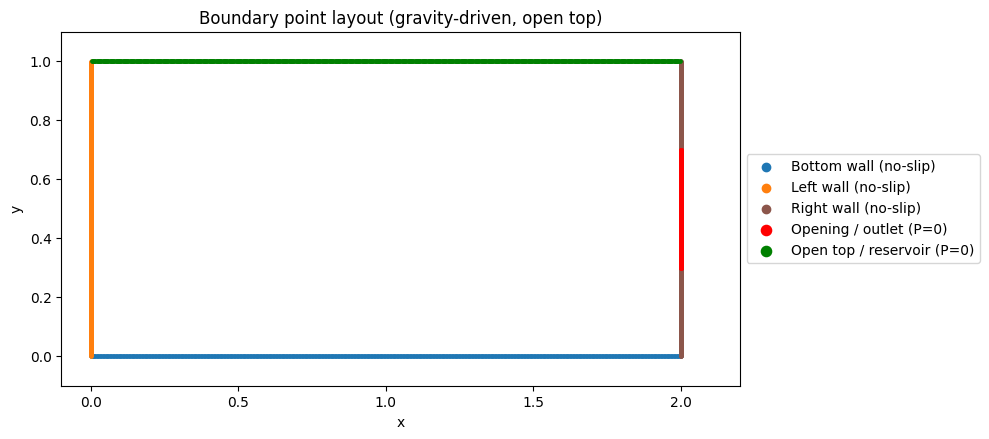

opening spans y = [0.300, 0.700]  at x = 2.0
Bottom wall : present (no-slip)
Left wall   : present (no-slip)
Right wall  : present (no-slip)
Top         : open boundary (P = 0), points in X_inlet only
time range of boundary samples: 0.000 .. 1.000


In [11]:
# [NEW] Visual + programmatic check of the boundary-point layout (spatial projection (x,y))
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {"Bottom wall": "tab:blue", "Left wall": "tab:orange", "Top wall": "tab:purple", "Right wall": "tab:brown"}
for name, arr in boundary_groups.items():
    ax.scatter(arr[:, 0], arr[:, 1], s=4, c=colors[name], label=f"{name} (no-slip)")
ax.scatter(X_open[:, 0].cpu(), X_open[:, 1].cpu(), s=6, c="red", label="Opening / outlet (P=0)")
ax.scatter(X_inlet[:, 0].cpu(), X_inlet[:, 1].cpu(), s=6, c="green", label="Open top / reservoir (P=0)")
ax.set_xlim(-0.1, L + 0.2); ax.set_ylim(-0.1, H + 0.1); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Boundary point layout (gravity-driven, open top)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), markerscale=3)
plt.tight_layout(); plt.show()

# ---- programmatic checks -------------------------------------------------
Xw = X_wall.cpu().numpy(); Xo = X_open.cpu().numpy(); Xi = X_inlet.cpu().numpy()
tol = 1e-9
on_right = np.isclose(Xw[:, 0], L)
assert not np.any(on_right & (Xw[:, 1] >= opening_y_min - tol) & (Xw[:, 1] <= opening_y_max + tol)), \
    "wall points found inside the opening!"
assert np.allclose(Xo[:, 0], L) and Xo[:, 1].min() >= opening_y_min - tol and Xo[:, 1].max() <= opening_y_max + tol
print(f"opening spans y = [{Xo[:,1].min():.3f}, {Xo[:,1].max():.3f}]  at x = {Xo[0,0]}")
assert not np.any(np.isclose(Xw[:, 1], H) & (Xw[:, 0] > tol) & (Xw[:, 0] < L - tol)), "wall points on the open top!"
assert np.allclose(Xi[:, 1], H) and Xi[:, 0].min() > 0 and Xi[:, 0].max() < L
for name in ["Bottom wall", "Left wall", "Right wall"]:
    print(f"{name:12s}: present (no-slip)")
print("Top         : open boundary (P = 0), points in X_inlet only")
print("time range of boundary samples:",
      f"{min(Xw[:,2].min(), Xo[:,2].min(), Xi[:,2].min()):.3f} .. {max(Xw[:,2].max(), Xo[:,2].max(), Xi[:,2].max()):.3f}")

In [12]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        
        # Output Scaling: The network inherently outputs O(1) values.
        # We scale the normalized pressure by p_scale (rho * g * H = 9810.0) 
        # inside the graph to match physical units without starving the gradients.
        p_physical = p_norm * 9810.0 
        
        return torch.cat([u, v, p_physical], dim=1)

In [13]:
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


tensor([[ 2.8774e-02,  2.3928e-02, -3.6798e+02]], grad_fn=<CatBackward0>)


In [14]:
print(pred[0,0].item())

0.02877393737435341


In [15]:
def derivatives(output, inputs):
    grad = torch.autograd.grad(
        output,
        inputs,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return grad

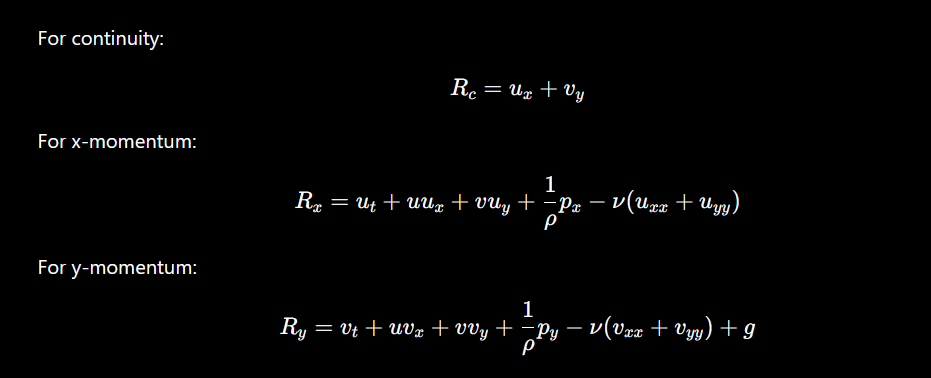

In [16]:
# continuity loss calculation
def continuity_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    v_y = derivatives(v, y)
    
    R_cont = u_x + v_y
    
    return R_cont

In [17]:
# x-momentum loss
# [CHANGED] u, v, p are now 1-D (N,) tensors.  With pred[:, 0:1] (N,1) the product u*u_x ((N,1)*(N,)) broadcast
# to (N,N) and the residual was meaningless.
def x_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0]
    v = pred[:, 1]
    p = pred[:, 2]          # p_dyn;  dP/dx = dp_dyn/dx  (gravity acts only in y)
    
    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    
    u_xx = derivatives(u_x, x)
    u_yy = derivatives(u_y, y)
    
    p_x = derivatives(p, x)

    u_t = derivatives(u, t)
    
    R_x = u_t + u*u_x + v*u_y + ((1/rho)*p_x) - nu*(u_xx + u_yy)
    
    return R_x

In [18]:
# y-momentum loss
# The network predicts the MODIFIED pressure  p_dyn = P + rho*g*y   (P = physical gauge pressure).
#   -(1/rho) dP/dy - g  =  -(1/rho) d(p_dyn)/dy      -> gravity is already inside p_dyn, so NO explicit g here
#   (adding -g again would double-count gravity).
# [CHANGED] 1-D tensors (see x-momentum cell)
def y_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0]
    v = pred[:, 1]
    p_dynamic = pred[:, 2]
    
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)
    
    v_xx = derivatives(v_x, x)
    v_yy = derivatives(v_y, y)

    v_t = derivatives(v, t)
    
    p_y = derivatives(p_dynamic, y)
    
    R_y = v_t + u*v_x + v*v_y + (1/rho)*p_y - nu*(v_xx + v_yy)

    return R_y

In [19]:
print(X_f[:, 0], X_f[:, 1], X_f[:, 2])

tensor([0.7491, 1.9014, 1.4640,  ..., 1.8934, 0.7950, 0.4343],
       grad_fn=<SelectBackward0>) tensor([0.3736, 0.3329, 0.1762,  ..., 0.3037, 0.4433, 0.1723],
       grad_fn=<SelectBackward0>) tensor([0.7300, 0.1845, 0.3466,  ..., 0.0195, 0.4010, 0.2574],
       grad_fn=<SelectBackward0>)


In [20]:
R_cont  = continuity_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_x     = x_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_y     = y_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])

# [NEW] shape guard - all residuals must be (N,)  (the old code produced (N,N) for R_x / R_y)
assert R_cont.shape == R_x.shape == R_y.shape == (X_f.shape[0],), (R_cont.shape, R_x.shape, R_y.shape)

print("Continuity residual:",
      R_cont.abs().mean().item())

print("X momentum residual:",
      R_x.abs().mean().item())

print("Y momentum residual:",
      R_y.abs().mean().item())

Continuity residual: 0.023813575506210327
X momentum residual: 0.34037110209465027
Y momentum residual: 0.25487402081489563


In [21]:
def physics_loss():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)
    R_x = x_momentum_loss(model, x, y, t)
    R_y = y_momentum_loss(model, x, y, t)

    loss_cont = torch.mean(R_cont**2)
    loss_x = torch.mean(R_x**2)
    loss_y = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y

In [22]:
# Wall boundary loss (u=0, v=0)   -- X_wall contains ONLY solid-wall points (no opening, no inlet)
def wall_loss():

    prediction = model(X_wall)

    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]

    loss_u = torch.mean(u_wall**2)
    loss_v = torch.mean(v_wall**2)

    return loss_u + loss_v

In [23]:
# [CHANGED] Opening (outlet) boundary condition:  physical gauge pressure P = 0
#   P = p_dyn - rho*g*y = 0   ->   p_dyn = rho*g*y
# u and v are deliberately NOT constrained here - the outflow must come out of the Navier-Stokes solution.
# The squared error is divided by p_scale^2 only to keep the loss O(1) (same minimiser as the plain MSE).
def opening_loss():
    
    prediction = model(X_open)

    p_dynamic = prediction[:, 2]
    y_open_tensor = X_open[:, 1]

    p_target = p_star_outlet(y_open_tensor)          # = rho * g * y

    return torch.mean(((p_dynamic - p_target) / p_scale)**2)

In [24]:
# [NEW] Open-top (reservoir) boundary condition = the driving mechanism
#   P = rho*g*h_head  ->  p_dyn = rho*g*(H + h_head)   (9810 Pa for h_head = 0)
# Velocity is NOT prescribed here (u = v = 0 would turn the top into a no-slip wall); it is part of the solution.
def inlet_loss():

    prediction = model(X_inlet)

    p_dynamic = prediction[:, 2]
    p_target = p_star_inlet(X_inlet[:, 1])

    return torch.mean(((p_dynamic - p_target) / p_scale)**2)

> **[REMOVED]** `pressure_reference_loss` (`p_dyn(0, H, 0) = 0`). The pressure level is now fixed by the outlet
> (`P = 0`) and the inlet, and this extra point condition **contradicts** them (e.g. in gravity mode the inlet
> requires `p_dyn(0, H) = rho*g*H ≈ 9810 Pa`).

## Initial condition

```
u(x, y, 0) = 0,   v(x, y, 0) = 0
```

The initial condition specifies the flow **at t = 0 only**. It does **not** drive the flow for `t > 0`.
The motion for `t > 0` is produced by the inlet/outlet pressure boundary conditions together with gravity
(inside `p_dyn`). Because the pressure BCs are applied from `t = 0`, this is an *impulsive start*: the pressure field
jumps instantly (incompressible fluid) and the velocity starts growing from zero.

In [25]:
# Initial condition loss  (points X_initial were generated together with the other point sets above)
def ic_loss():
    pred = model(X_initial)
    u_ic = pred[:, 0]
    v_ic = pred[:, 1]
    return torch.mean(u_ic**2) + torch.mean(v_ic**2)

In [26]:
# Total loss
# Loss weights - tune these.
# [CHANGED] lambda_ref removed, lambda_inlet added; every term now returned separately for tracking
lambda_phys  = 1.0
lambda_wall  = 10.0
lambda_open  = 10.0
lambda_inlet = 10.0
lambda_ic    = 10.0

def total_loss():

    L_phys  = physics_loss()
    L_wall  = wall_loss()
    L_open  = opening_loss()
    L_inlet = inlet_loss()
    L_ic    = ic_loss()

    loss = (
        lambda_phys  * L_phys +
        lambda_wall  * L_wall +
        lambda_open  * L_open +
        lambda_inlet * L_inlet +
        lambda_ic    * L_ic
    )

    return loss, L_phys, L_wall, L_open, L_inlet, L_ic

In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=200
)


In [28]:
# # [CHANGED] Training from scratch with the corrected problem.
# RUN_TRAINING = True  # Ensure this is True to actually run training

# epochs_adam = 5000
# resample_every = 200   # refresh collocation points periodically
# loss_history = []                 
# loss_components_history = []      
# model_is_trained = False
# lbfgs_steps = 0  # Defined at the global cell level

# def resample_collocation_points():
#     global X_f
#     x_f = np.random.uniform(0, L, N_f)
#     y_f = np.random.uniform(0, H, N_f)
#     t_f = np.random.uniform(0, T, N_f)
#     X_new = np.column_stack([x_f, y_f, t_f])
#     X_f = torch.tensor(X_new, dtype=torch.float32, device=device, requires_grad=True)

# checkpoint_path = "pinn_model_03_gravity.pt"

# if RUN_TRAINING:
#     torch.manual_seed(42); np.random.seed(42)
#     model = PINN().to(device)
    
#     # --- Phase 1: Adam Optimizer ---
#     optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.5, patience=200)

#     print("Starting Phase 1: Adam Training...")
#     for epoch in range(epochs_adam):
#         if epoch % resample_every == 0 and epoch > 0:
#             resample_collocation_points()

#         optimizer_adam.zero_grad()
#         (loss, L_phys, L_wall, L_open, L_inlet, L_ic) = total_loss()
#         loss.backward()
#         optimizer_adam.step()
#         scheduler.step(loss.item())

#         loss_history.append(loss.item())
#         loss_components_history.append(
#             (L_phys.item(), L_wall.item(), L_open.item(), L_inlet.item(), L_ic.item())
#         )

#         if epoch % 100 == 0:
#             print(f"Adam Epoch {epoch+1:5d} | Total: {loss.item():.6f} | PDE: {L_phys.item():.6f}")

#     # --- Phase 2: L-BFGS Optimizer ---
#     print("\nStarting Phase 2: L-BFGS Training...")
#     optimizer_lbfgs = torch.optim.LBFGS(
#         model.parameters(),
#         lr=1.0,
#         max_iter=10000,
#         max_eval=12500,
#         history_size=50,
#         tolerance_grad=1e-5,
#         tolerance_change=1.0 * np.finfo(float).eps,
#         line_search_fn="strong_wolfe"
#     )

#     def closure():
#         global lbfgs_steps
#         optimizer_lbfgs.zero_grad()
#         (loss, L_phys, L_wall, L_open, L_inlet, L_ic) = total_loss()
#         loss.backward()
        
#         loss_history.append(loss.item())
#         loss_components_history.append(
#             (L_phys.item(), L_wall.item(), L_open.item(), L_inlet.item(), L_ic.item())
#         )

#         if lbfgs_steps % 100 == 0:
#             print(f"L-BFGS Step {lbfgs_steps:5d} | Total: {loss.item():.6f} | PDE: {L_phys.item():.6f}")
        
#         lbfgs_steps += 1
#         return loss

#     optimizer_lbfgs.step(closure)

#     model_is_trained = True
#     torch.save({
#         "epoch": epochs_adam + lbfgs_steps,
#         "flow_mode": "gravity",
#         "params": dict(L=L, H=H, T=T, rho=rho, nu=nu, g=g, h_head=h_head,
#                        opening=(opening_y_min, opening_y_max)),
#         "model_state_dict": model.state_dict(),
#         "optimizer_state_dict": optimizer_adam.state_dict(),
#         "loss_history": loss_history,
#         "loss_components_history": loss_components_history,
#     }, checkpoint_path)
#     print(f"\nTraining complete. Checkpoint saved to {checkpoint_path}")
# else:
#     print("RUN_TRAINING = False -> no training performed.")

In [29]:
# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\upadated_gravity\pinn_model_03_gravity_03_07.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\upadated_gravity\pinn_model_03_gravity_03_07.pt  (epochs = 15929)


C:\Users\ps302\AppData\Local\Temp\ipykernel_18796\2983754739.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

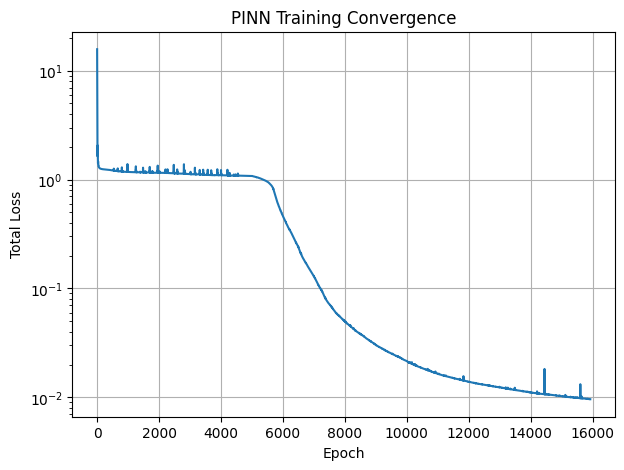

In [30]:
import matplotlib.pyplot as plt
if len(loss_history) == 0:
    print("No loss history (model not trained in this session).")
else:
    plt.figure(figsize=(7, 5))

    plt.semilogy(
        loss_history
    )

    plt.xlabel("Epoch")
    plt.ylabel("Total Loss")
    plt.title("PINN Training Convergence")

    plt.grid(True)
    plt.show()

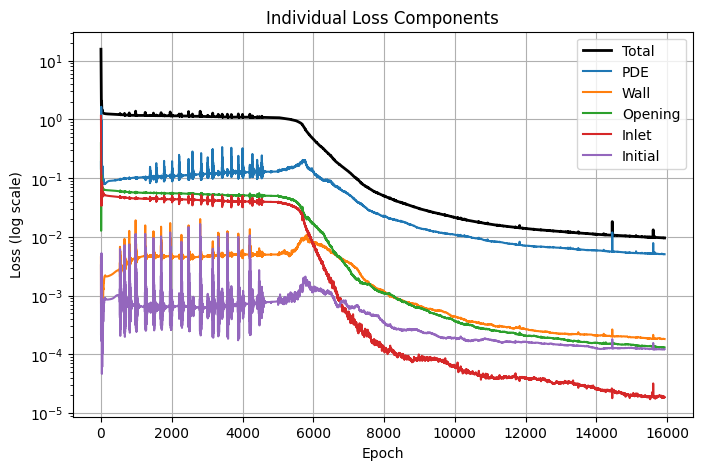

In [31]:
import numpy as np
# [CHANGED] components: pde, wall, opening, inlet, initial (+ total)
if len(loss_components_history) == 0:
    print("No loss history (model not trained in this session).")
else:
    components = np.array(loss_components_history)
    labels = ["PDE", "Wall", "Opening", "Inlet", "Initial"]

    plt.figure(figsize=(8, 5))
    plt.semilogy(loss_history, "k", lw=2, label="Total")
    for i, label in enumerate(labels):
        plt.semilogy(components[:, i], label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.title("Individual Loss Components")
    plt.legend()
    plt.grid(True)
    plt.show()

In [32]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [33]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)
v_pred = v_pred.reshape(Ny, Nx)
p_dynamic_pred = p_dynamic_pred.reshape(Ny, Nx)

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * Y
p_pred = p_dynamic_pred + p_hydrostatic


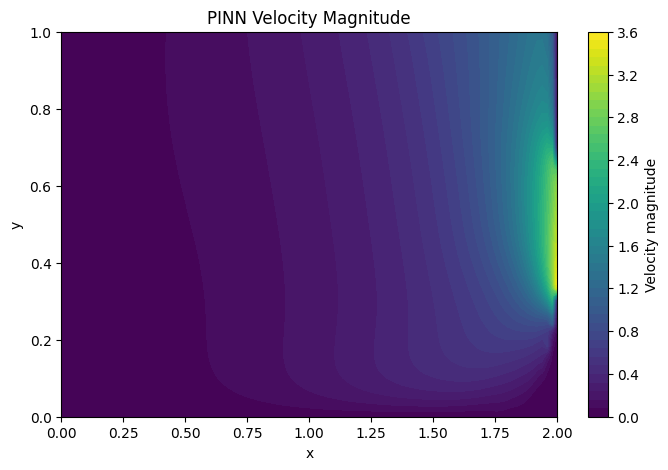

In [35]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

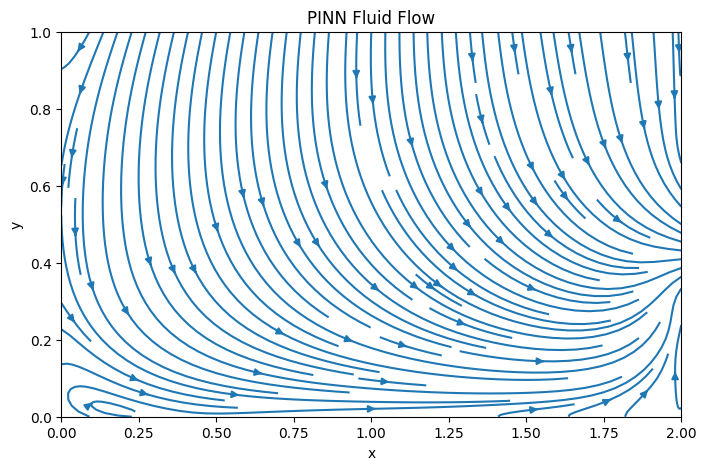

In [36]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow")

plt.show()

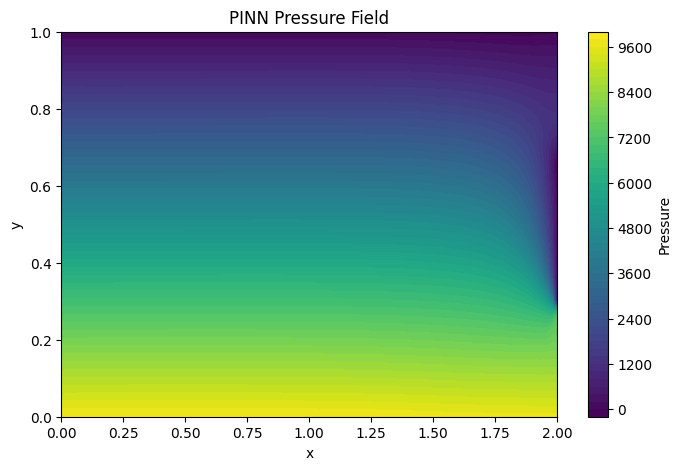

In [37]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [38]:
# Generating opening points for EVALUATION at t = T
# [CHANGED] renamed X_open -> X_open_eval; the old code overwrote the training tensor X_open here
N_open_eval = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open_eval)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open_eval = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open_eval.shape

torch.Size([500, 3])

In [39]:
with torch.no_grad():

    opening_prediction = model(X_open_eval)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)   P = p_dyn - rho*g*y
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open

In [40]:
for i in range(0, N_open_eval, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )

y = 0.300 m | u = 0.45903 m/s | v = 0.29459 m/s | p = 73.38696 Pa
y = 0.340 m | u = 2.97316 m/s | v = 1.94627 m/s | p = 58.98623 Pa
y = 0.380 m | u = 3.46730 m/s | v = 0.57065 m/s | p = 76.09747 Pa
y = 0.420 m | u = 3.40465 m/s | v = -0.51235 m/s | p = 29.95114 Pa
y = 0.460 m | u = 3.11846 m/s | v = -1.34970 m/s | p = -26.73621 Pa
y = 0.500 m | u = 2.72023 m/s | v = -1.98001 m/s | p = -42.90550 Pa
y = 0.540 m | u = 2.27446 m/s | v = -2.41176 m/s | p = -13.97712 Pa
y = 0.581 m | u = 1.82399 m/s | v = -2.66229 m/s | p = 20.53719 Pa
y = 0.621 m | u = 1.31413 m/s | v = -2.64552 m/s | p = -45.44508 Pa
y = 0.661 m | u = 0.55599 m/s | v = -1.56322 m/s | p = -46.80382 Pa


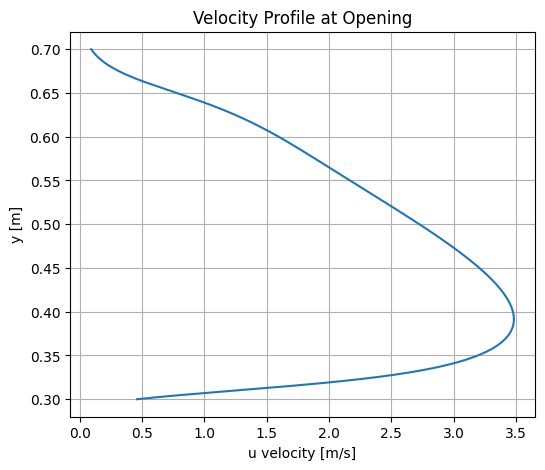

In [41]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

In [42]:
Q = np.trapezoid(
    u_open,
    y_open
)

print(
    f"Flow rate per unit depth = {Q:.6f} m^2/s"
)

Flow rate per unit depth = 0.891042 m^2/s


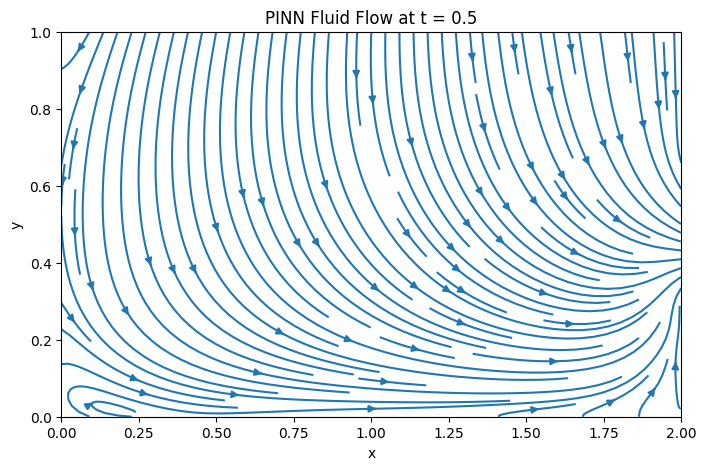

In [43]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


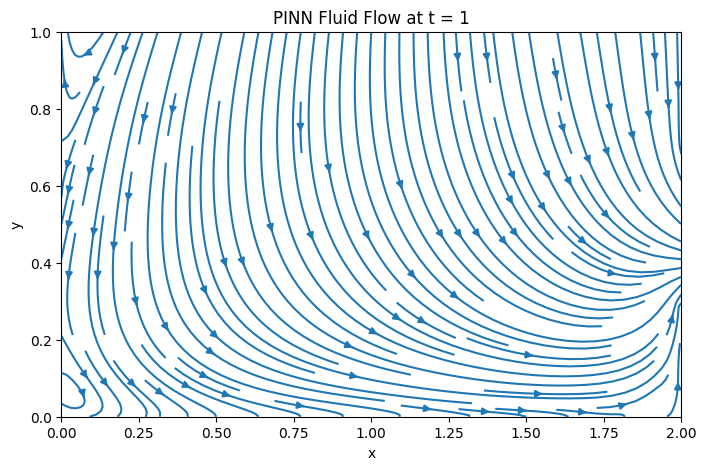

In [44]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


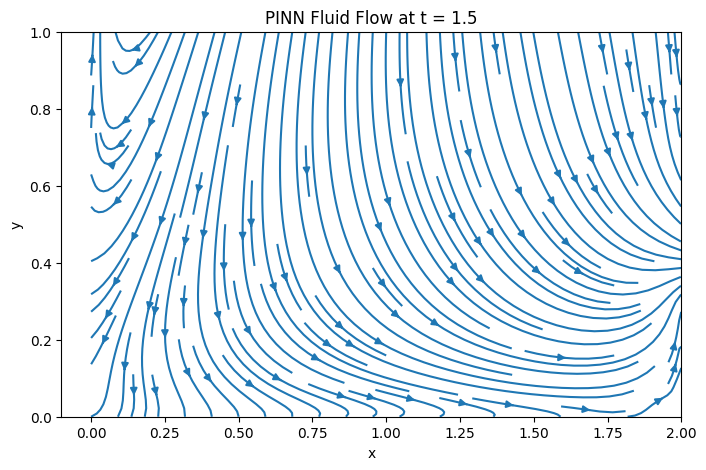

In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


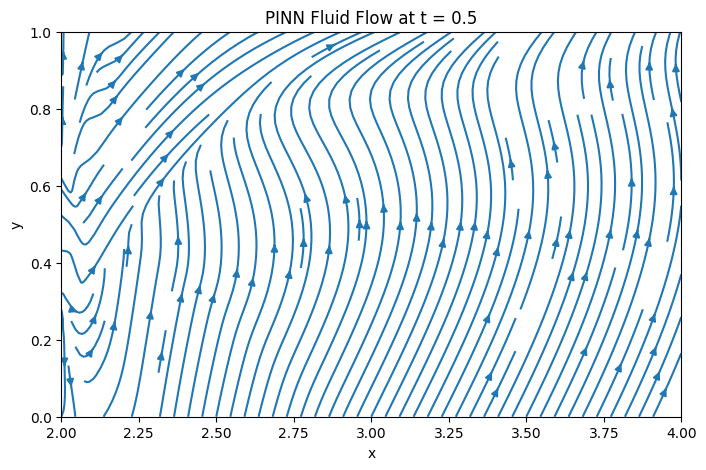

In [46]:
# WARNING: x in [2, 4] lies OUTSIDE the computational domain (0 <= x <= L = 2): this is network
# extrapolation, not a flow solution. Kept from the original notebook only for reference.
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(2, 4, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [47]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

In [48]:
with torch.no_grad():
    test_pnts = torch.tensor([[0.2, 0.70, 0.5]], dtype=torch.float32, device=device)
    prediction = model(test_pnts)


u_pred = prediction[:, 0].item()
v_pred = prediction[:, 1].item()
p_dynamic_pred = prediction[:, 2].item()

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * 0.70
p_pred = p_dynamic_pred + p_hydrostatic

print(f"u_pred: {u_pred} m/s")
print(f"v_pred: {v_pred} m/s") 
print(f"p_pred: {p_pred} Pa")

u_pred: -0.004501029849052429 m/s
v_pred: -0.039503514766693115 m/s
p_pred: 2936.08984375 Pa


In [49]:
import numpy as np
import torch

model.eval()
rng_val = np.random.default_rng(2024)
nv = 201
t_prof = [0.25, 0.5, 0.75, 1.0]

# Generate coordinates for the opening (outlet)
y_prof = np.linspace(opening_y_min, opening_y_max, nv)
x_open_line = np.full_like(y_prof, L)

# 1. Calculate Bernoulli Estimate (Theoretical Max Speed)
y_in_s  = np.array([H])
y_out_s = np.linspace(opening_y_min, opening_y_max, 50)
head = (p_star_inlet(y_in_s)[:, None] - p_star_outlet(y_out_s)[None, :]) / rho
U_bern = float(np.sqrt(2.0 * max(head.max(), 1e-12)))

def predict_uvp(x, y, t):
    X_ = torch.tensor(np.column_stack([x, y, t]), dtype=torch.float32, device=device)
    with torch.no_grad():
        out = model(X_).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]

print("================ PINN PHYSICS VALIDATION ================")
print(f"Bernoulli upper-bound speed (U_bern): {U_bern:.3f} m/s\n")
print(f"{'Time':<6} | {'Mass Flux In':<14} | {'Mass Flux Out':<14} | {'Imbalance':<10} | {'Max Vel (u)':<12} | {'Outflow %':<10} | {'TV Smoothness'}")
print("-" * 105)

for tp in t_prof:
    # Get predictions at the outlet
    u_out, v_out, pd_out = predict_uvp(x_open_line, y_prof, np.full_like(y_prof, tp))
    
    # Calculate Mass Flux Out (Integral of u-velocity over the opening)
    Q_out = np.trapezoid(u_out, y_prof)
    
    # Calculate Mass Flux In (Integral of v-velocity over the open top)
    xs = np.linspace(0, L, nv)
    _, vt, _ = predict_uvp(xs, np.full_like(xs, H), np.full_like(xs, tp))
    Q_in = -np.trapezoid(vt, xs)  # normal is in the -y direction
    
    # Mass Balance Imbalance
    imb = abs(Q_in - Q_out) / max(abs(Q_out), abs(Q_in), 1e-12)
    
    # Max velocity & Outflow percentage
    max_u = np.max(np.abs(u_out))
    outflow_pct = 100 * np.mean(u_out > 0)
    
    # Total Variation (TV) Smoothness
    tv = np.sum(np.abs(np.diff(u_out))) / max(np.ptp(u_out), 1e-12)
    
    print(f"{tp:<6.2f} | {Q_in:<14.5f} | {Q_out:<14.5f} | {imb:<10.2%} | {max_u:<12.3f} | {outflow_pct:<10.1f} | {tv:.2f}")

print("\n--- Diagnostic Guide ---")
print("1. Imbalance: Should be < 10%. (If high, mass is 'leaking' and continuity loss is too weak).")
print("2. Max Vel (u): Should be a reasonable fraction of U_bern (not exceeding it, not practically 0).")
print("3. Outflow %: Should be ~100% (flow is going out, not getting sucked backward).")
print("4. TV Smoothness: Should be 1.0 - 3.0 (If >> 3, the profile is noisy/oscillating).")

================ PINN PHYSICS VALIDATION ================
Bernoulli upper-bound speed (U_bern): 3.706 m/s

Time   | Mass Flux In   | Mass Flux Out  | Imbalance  | Max Vel (u)  | Outflow %  | TV Smoothness
---------------------------------------------------------------------------------------------------------
0.25   | 0.68212        | 0.77918        | 12.46%     | 3.017        | 97.5       | 1.95
0.50   | 0.83745        | 0.87651        | 4.46%      | 3.401        | 100.0      | 1.99
0.75   | 0.87113        | 0.88224        | 1.26%      | 3.476        | 100.0      | 1.96
1.00   | 0.87489        | 0.89102        | 1.81%      | 3.483        | 100.0      | 1.89

--- Diagnostic Guide ---
1. Imbalance: Should be < 10%. (If high, mass is 'leaking' and continuity loss is too weak).
2. Max Vel (u): Should be a reasonable fraction of U_bern (not exceeding it, not practically 0).
3. Outflow %: Should be ~100% (flow is going out, not getting sucked backward).
4. TV Smoothness: Should be 1.0 - 3.0

In [50]:
import numpy as np
import torch

# Ensure the model is in evaluation mode
model.eval()

# Parameters based on your setup
rho = 1000.0
g = 9.81
L = 2.0
H = 1.0

# ==========================================
# Checks A & B: Outlet metrics at t = 0.5
# ==========================================
N_eval = 500
y_eval = np.linspace(0.30, 0.70, N_eval)
x_eval = np.full_like(y_eval, L)
t_eval = np.full_like(y_eval, 0.5)

X_eval_tensor = torch.tensor(
    np.column_stack([x_eval, y_eval, t_eval]), 
    dtype=torch.float32, 
    device=device
)

with torch.no_grad():
    pred = model(X_eval_tensor)
    u_out = pred[:, 0].cpu().numpy()
    p_dyn_out = pred[:, 2].cpu().numpy()

# Reconstruct physical pressure:
# P = p_dynamic - rho*g*y
P_physical = p_dyn_out - (rho * g * y_eval)

# Check A calculations
mean_P = np.mean(np.abs(P_physical))
max_P = np.max(np.abs(P_physical))
rmse_P = np.sqrt(np.mean(P_physical**2))

print("--- A. Outlet Pressure (P) at t=0.5 ---")
print(f"Mean |P|: {mean_P:.4f} Pa")
print(f"Max  |P|: {max_P:.4f} Pa")
print(f"RMSE (P): {rmse_P:.4f} Pa\n")

# Check B calculations
Q = np.trapezoid(u_out, y_eval)

print("--- B. Outlet Flow Rate (Q) at t=0.5 ---")
print(f"Q = {Q:.6f} m^2/s\n")


# ==========================================
# Check C: PDE Residuals at new random points
# ==========================================
N_res = 10000
x_res = np.random.uniform(0, L, N_res)
y_res = np.random.uniform(0, H, N_res)
t_res = np.random.uniform(0, 1.0, N_res)

x_res_t = torch.tensor(x_res, dtype=torch.float32, device=device, requires_grad=True)
y_res_t = torch.tensor(y_res, dtype=torch.float32, device=device, requires_grad=True)
t_res_t = torch.tensor(t_res, dtype=torch.float32, device=device, requires_grad=True)

# Calculate residuals using your existing derivative functions
R_cont = continuity_loss(model, x_res_t, y_res_t, t_res_t).detach().cpu().numpy()
R_x = x_momentum_loss(model, x_res_t, y_res_t, t_res_t).detach().cpu().numpy()
R_y = y_momentum_loss(model, x_res_t, y_res_t, t_res_t).detach().cpu().numpy()

rmse_cont = np.sqrt(np.mean(R_cont**2))
rmse_x = np.sqrt(np.mean(R_x**2))
rmse_y = np.sqrt(np.mean(R_y**2))

print("--- C. PDE Residuals (New Random Points) ---")
print(f"Continuity RMSE : {rmse_cont:.6e}")
print(f"X-momentum RMSE : {rmse_x:.6e}")
print(f"Y-momentum RMSE : {rmse_y:.6e}")

--- A. Outlet Pressure (P) at t=0.5 ---
Mean |P|: 51.7668 Pa
Max  |P|: 485.6060 Pa
RMSE (P): 92.0266 Pa

--- B. Outlet Flow Rate (Q) at t=0.5 ---
Q = 0.876522 m^2/s

--- C. PDE Residuals (New Random Points) ---
Continuity RMSE : 6.325141e-01
X-momentum RMSE : 1.601932e+01
Y-momentum RMSE : 2.544730e+00


In [51]:
# model = PINNModel()
# num1 = torch.tensor([[2.0]], dtype=torch.float32, device=device)
# num2 = torch.tensor([[3.0]], dtype=torch.float32, device=device)
# num3 = torch.tensor([[4.0]], dtype=torch.float32, device=device)

# output = model(num1, num2, num3)

# u = output[..., 0]
# v = output[..., 1]

# print(u, v)

In [52]:
# Try -> 0.3 - 0.8
# try -> 0.3 - 0.9
# try -> 0.1 - 0.7
# try -> 0.2 - 0.7
# try -> actual naviar stokes equation 

---
# Post-training validation (Steps 8-12)

Passing the PDE residual check alone does **not** prove the solution is correct. It only shows that the network
approximately satisfies the governing equations. Correctness additionally needs: BC + IC satisfaction, a consistent
physical setup, and an independent reference solution. All of that is checked below, **on points that were not used
for training**.

> Run this section only after training (`RUN_TRAINING = True`) or after loading a checkpoint.

In [53]:
# ================= Helpers for validation =================
model.eval()
if not model_is_trained:
    print("!" * 70)
    print("WARNING: model is NOT trained (no training run / checkpoint). Numbers below are meaningless.")
    print("!" * 70)

rng_val = np.random.default_rng(2024)           # different from the training seed
nv = 201
t_check = np.linspace(0.0, T, 11)
report = {}                                      # filled below, printed in the final report

def predict_uvp(x, y, t):
    X_ = torch.tensor(np.column_stack([x, y, t]), dtype=torch.float32, device=device)
    with torch.no_grad():
        out = model(X_).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]

def physical_pressure(p_dyn, y):
    return p_dyn - rho * g * y                    # P = p_dyn - rho g y

def pde_residuals(X_np, chunk=5000):
    # returns residuals AND the pressure-gradient magnitude (a natural scale to judge the momentum residual)
    Rc, Rx, Ry, Gx, Gy = [], [], [], [], []
    for i in range(0, len(X_np), chunk):
        Xc = torch.tensor(X_np[i:i + chunk], dtype=torch.float32, device=device, requires_grad=True)
        x_, y_, t_ = Xc[:, 0], Xc[:, 1], Xc[:, 2]
        Rc.append(continuity_loss(model, x_, y_, t_).detach().cpu().numpy())
        Rx.append(x_momentum_loss(model, x_, y_, t_).detach().cpu().numpy())
        Ry.append(y_momentum_loss(model, x_, y_, t_).detach().cpu().numpy())
        p_ = model(Xc)[:, 2]
        gp = torch.autograd.grad(p_.sum(), Xc)[0].detach().cpu().numpy()
        Gx.append(gp[:, 0] / rho); Gy.append(gp[:, 1] / rho)
    return [np.concatenate(a) for a in (Rc, Rx, Ry, Gx, Gy)]

def rms(a):  return float(np.sqrt(np.mean(np.square(a))))
def mabs(a): return float(np.mean(np.abs(a)))
def xabs(a): return float(np.max(np.abs(a)))

# Bernoulli (inviscid, steady) estimate of the largest outlet speed:  0.5*U^2 = max(p*_in - p*_out)/rho
y_in_s  = np.array([H])
y_out_s = np.linspace(opening_y_min, opening_y_max, 50)
head = (p_star_inlet(y_in_s)[:, None] - p_star_outlet(y_out_s)[None, :]) / rho
U_bern = float(np.sqrt(2.0 * max(head.max(), 1e-12)))
print(f"Bernoulli speed estimate (upper-bound scale for viscous, transient flow): U_bern = {U_bern:.3f} m/s")

Bernoulli speed estimate (upper-bound scale for viscous, transient flow): U_bern = 3.706 m/s


In [54]:
# ================= STEP 8 : boundary / initial condition errors =================
def zeros(S): return np.zeros_like(S)
def full(c):  return lambda S: np.full_like(S, c)
def ident(S): return S

def st_mesh(s):
    S, TT = np.meshgrid(s, t_check)
    return S.ravel(), TT.ravel()

# ---- solid walls ----
walls = {}
walls["Bottom wall"] = (ident, zeros, seg(0, L, 2 * nv))
walls["Left wall"] = (zeros, ident, seg(0, H, 2 * nv))
walls["Top wall"]  = None                                       # top is open (reservoir), not a wall
s_right = np.concatenate([seg(0, opening_y_min, nv, True, False), seg(opening_y_max, H, nv, False, True)])
walls["Right wall"] = (full(L), ident, s_right)

report["wall"] = {}
for name in ["Left wall", "Bottom wall", "Top wall", "Right wall"]:
    if walls[name] is None:
        report["wall"][name] = None
        continue
    xf, yf, s = walls[name]
    S, TT = st_mesh(s)
    u_, v_, _ = predict_uvp(xf(S), yf(S), TT)
    report["wall"][name] = (xabs(u_), xabs(v_))
    print(f"{name:12s}: max|u| = {xabs(u_):.3e}   max|v| = {xabs(v_):.3e}   (expected ~ 0)")

# ---- opening pressure:  p_dyn - rho g y  (= physical gauge pressure) ----
S, TT = st_mesh(np.linspace(opening_y_min, opening_y_max, nv))
_, _, pd_ = predict_uvp(np.full_like(S, L), S, TT)
e_open = pd_ - rho * g * S
report["open_p"] = (xabs(e_open), rms(e_open))
print(f"Opening pressure error  p_dyn - rho*g*y :  max = {xabs(e_open):.3e} Pa,  rms = {rms(e_open):.3e} Pa"
      f"   (p_scale = {p_scale:.0f} Pa)")

# ---- open top: p_dyn - rho*g*(H+h_head) ----
S, TT = st_mesh(seg(0, L, nv, False, False))
ui, vi, pdi = predict_uvp(S, np.full_like(S, H), TT)
e_in = pdi - p_star_inlet(np.full_like(S, H))
report["inlet"] = (xabs(e_in), rms(e_in))
print(f"Open-top pressure error  p_dyn - rho*g*(H+h_head) :  max = {xabs(e_in):.3e} Pa,  rms = {rms(e_in):.3e} Pa")

# ---- initial condition ----
Xic = np.column_stack([rng_val.uniform(0, L, 5000), rng_val.uniform(0, H, 5000), np.zeros(5000)])
u0, v0, _ = predict_uvp(Xic[:, 0], Xic[:, 1], Xic[:, 2])
report["ic"] = (xabs(u0), xabs(v0))
print(f"Initial condition t=0 :  max|u| = {xabs(u0):.3e}   max|v| = {xabs(v0):.3e}   (expected ~ 0)")

Left wall   : max|u| = 9.023e-03   max|v| = 1.652e-02   (expected ~ 0)
Bottom wall : max|u| = 9.407e-02   max|v| = 6.115e-02   (expected ~ 0)
Right wall  : max|u| = 3.656e-01   max|v| = 2.206e-01   (expected ~ 0)
Opening pressure error  p_dyn - rho*g*y :  max = 2.216e+03 Pa,  rms = 1.938e+02 Pa   (p_scale = 9810 Pa)
Open-top pressure error  p_dyn - rho*g*(H+h_head) :  max = 1.875e+02 Pa,  rms = 4.616e+01 Pa
Initial condition t=0 :  max|u| = 2.801e-01   max|v| = 2.745e-01   (expected ~ 0)


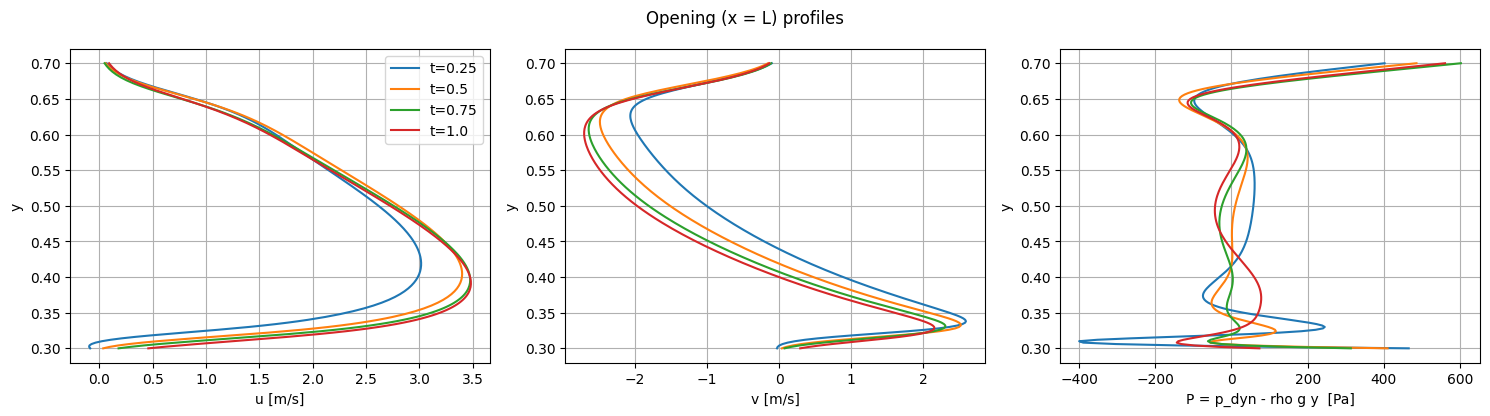

Residuals on the opening line:  RMSE(cont) = 9.197e+00 1/s,  RMSE(x-mom) = 2.449e+02,  RMSE(y-mom) = 7.064e+01 m/s^2
Opening pressure BC error (max) = 2.216e+03 Pa

  t   |  u_min     u_max     |  v_min     v_max   | %u>0 (outflow) | max|u|/U_bern | TV ratio
 0.25 |   -0.0959    3.0165 |   -2.0664    2.5968 |     97.5%      |    0.814      |   1.95
 0.50 |    0.0366    3.4008 |   -2.4891    2.5253 |    100.0%      |    0.918      |   1.99
 0.75 |    0.0493    3.4763 |   -2.6453    2.3107 |    100.0%      |    0.938      |   1.96
 1.00 |    0.0910    3.4831 |   -2.7082    2.1583 |    100.0%      |    0.940      |   1.89
  (TV ratio ~1-3: smooth profile; >>3: oscillatory.  max|u|/U_bern should be O(0.1-1); ~1e-4 means 'no flow'.)

  t   |  Q_in (open top)  Q_out (opening) [m^2/s]  | rel. imbalance
 0.25 |      0.68212       0.77918   |   12.46%
 0.50 |      0.83745       0.87651   |    4.46%
 0.75 |      0.87113       0.88224   |    1.26%
 1.00 |      0.87489       0.89102   |    1.81%


In [55]:
# ================= STEP 9 : opening velocity solution =================
t_prof = [0.25, 0.5, 0.75, 1.0]
y_prof = np.linspace(opening_y_min, opening_y_max, nv)
x_open_line = np.full_like(y_prof, L)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
report["open_profile"] = {}
for tp in t_prof:
    u_, v_, pd_ = predict_uvp(x_open_line, y_prof, np.full_like(y_prof, tp))
    P_ = physical_pressure(pd_, y_prof)
    report["open_profile"][tp] = (u_, v_, P_)
    ax[0].plot(u_, y_prof, label=f"t={tp}"); ax[1].plot(v_, y_prof); ax[2].plot(P_, y_prof)
ax[0].set_xlabel("u [m/s]"); ax[1].set_xlabel("v [m/s]"); ax[2].set_xlabel("P = p_dyn - rho g y  [Pa]")
for a in ax: a.set_ylabel("y"); a.grid(True)
ax[0].legend(); fig.suptitle("Opening (x = L) profiles"); plt.tight_layout(); plt.show()

# ---- (1) continuity + (2) momentum + (3) BC at the opening points ----
S, TT = st_mesh(np.linspace(opening_y_min, opening_y_max, nv))
Rc, Rx, Ry, Gx, Gy = pde_residuals(np.column_stack([np.full_like(S, L), S, TT]))
print("Residuals on the opening line:  "
      f"RMSE(cont) = {rms(Rc):.3e} 1/s,  RMSE(x-mom) = {rms(Rx):.3e},  RMSE(y-mom) = {rms(Ry):.3e} m/s^2")
print(f"Opening pressure BC error (max) = {report['open_p'][0]:.3e} Pa")

# ---- (4) direction of flow, (5) magnitude, (6) smoothness ----
print("\n  t   |  u_min     u_max     |  v_min     v_max   | %u>0 (outflow) | max|u|/U_bern | TV ratio")
report["u_all"] = []; report["v_all"] = []
for tp in t_prof:
    u_, v_, P_ = report["open_profile"][tp]
    report["u_all"].append(u_); report["v_all"].append(v_)
    tv = np.sum(np.abs(np.diff(u_))) / max(np.ptp(u_), 1e-12)
    print(f" {tp:4.2f} | {u_.min():9.4f} {u_.max():9.4f} | {v_.min():9.4f} {v_.max():9.4f} | "
          f"{100*np.mean(u_ > 0):8.1f}%      | {np.max(np.abs(u_))/U_bern:8.3f}      | {tv:6.2f}")
print("  (TV ratio ~1-3: smooth profile; >>3: oscillatory.  max|u|/U_bern should be O(0.1-1); ~1e-4 means 'no flow'.)")

# ---- mass balance: flux in (inlet) must equal flux out (opening) at every time ----
print("\n  t   |  Q_in (open top)  Q_out (opening) [m^2/s]  | rel. imbalance")
report["imbalance"] = []
for tp in t_prof:
    u_, v_, _ = report["open_profile"][tp]
    Q_out = np.trapezoid(u_, y_prof)
    xs = np.linspace(0, L, nv)
    _, vt, _ = predict_uvp(xs, np.full_like(xs, H), np.full_like(xs, tp))
    Q_in = -np.trapezoid(vt, xs)                # inward normal at the open top is -y
    imb = abs(Q_in - Q_out) / max(abs(Q_out), abs(Q_in), 1e-12)
    report["imbalance"].append(imb)
    print(f" {tp:4.2f} | {Q_in:12.5f} {Q_out:13.5f}   | {imb:8.2%}")

In [56]:
# ================= STEP 10 : PDE residual on FRESH collocation points =================
N_val = 20000
X_val = np.column_stack([rng_val.uniform(0, L, N_val), rng_val.uniform(0, H, N_val), rng_val.uniform(0, T, N_val)])
Rc, Rx, Ry, Gx, Gy = pde_residuals(X_val)

report["pde"] = {
    "Continuity": (mabs(Rc), rms(Rc), xabs(Rc)),
    "X-momentum": (mabs(Rx), rms(Rx), xabs(Rx)),
    "Y-momentum": (mabs(Ry), rms(Ry), xabs(Ry)),
}
report["pde_rel_x"] = rms(Rx) / max(rms(Gx), 1e-12)     # residual relative to the pressure-gradient term
report["pde_rel_y"] = rms(Ry) / max(rms(Gy), 1e-12)

print(f"{'':12s} {'mean|R|':>12s} {'RMSE':>12s} {'max|R|':>12s}")
for k, (a, b, c) in report["pde"].items():
    print(f"{k:12s} {a:12.3e} {b:12.3e} {c:12.3e}")
print(f"\nRMSE(R_x) / RMS(p_x/rho) = {report['pde_rel_x']:.3e},   RMSE(R_y) / RMS(p_y/rho) = {report['pde_rel_y']:.3e}")
print("A small residual only says the network solves the PDE approximately; it does NOT prove the solution is right.")

                  mean|R|         RMSE       max|R|
Continuity      4.090e-02    7.534e-01    5.637e+01
X-momentum      6.541e-02    9.631e-01    6.867e+01
Y-momentum      6.201e-02    1.456e+00    1.260e+02

RMSE(R_x) / RMS(p_x/rho) = 1.675e-01,   RMSE(R_y) / RMS(p_y/rho) = 5.868e-01
A small residual only says the network solves the PDE approximately; it does NOT prove the solution is right.


In [57]:
# ================= STEP 11 : comparison with a reference (analytical / CFD) solution =================
# There is NO closed-form solution for this geometry (tank + opening + impulsive start), so a trusted CFD result
# (OpenFOAM, COMSOL, Fluent, ...) is required.  It must use the SAME geometry, nu, rho, g, initial condition,
# boundary conditions (open top with P = 0, outlet P = 0) and the SAME pressure reference.
#
# Expected file format (numpy .npz, one row per sample point):
#     x, y, t   : coordinates
#     u, v      : velocity components [m/s]
#     p         : PHYSICAL GAUGE pressure P (outlet = 0), NOT the modified pressure p_dyn
REFERENCE_FILE = "reference_solution.npz"
report["ref"] = None

def rel_l2(a, b): return float(np.linalg.norm(a - b) / max(np.linalg.norm(b), 1e-12))

if not os.path.exists(REFERENCE_FILE):
    print(f"'{REFERENCE_FILE}' not found -> NO reference comparison performed (accuracy against truth is UNVERIFIED).")
else:
    ref = np.load(REFERENCE_FILE)
    xr, yr, tr, ur, vr, pr = (ref[k] for k in ("x", "y", "t", "u", "v", "p"))
    up, vp, pdp = predict_uvp(xr, yr, tr)
    pp = physical_pressure(pdp, yr)
    report["ref"] = {}
    print(f"{'':3s} {'MSE':>12s} {'RMSE':>12s} {'rel L2':>12s}")
    for name, a, b in (("u", up, ur), ("v", vp, vr), ("p", pp, pr)):
        mse = float(np.mean((a - b) ** 2))
        report["ref"][name] = (mse, np.sqrt(mse), rel_l2(a, b))
        print(f"{name:3s} {mse:12.4e} {np.sqrt(mse):12.4e} {rel_l2(a, b):12.4e}")

    # ---- contours + streamlines at the reference time closest to T ----
    from scipy.interpolate import griddata
    t_cmp = tr[np.argmin(np.abs(tr - T))]
    m = np.isclose(tr, t_cmp)
    gx, gy = np.meshgrid(np.linspace(0, L, 200), np.linspace(0, H, 100))
    interp = lambda f: griddata((xr[m], yr[m]), f[m], (gx, gy), method="linear")
    ur_g, vr_g, pr_g = interp(ur), interp(vr), interp(pr)
    up_, vp_, pdp_ = predict_uvp(gx.ravel(), gy.ravel(), np.full(gx.size, t_cmp))
    up_g, vp_g = up_.reshape(gx.shape), vp_.reshape(gx.shape)
    pp_g = physical_pressure(pdp_, gy.ravel()).reshape(gx.shape)

    for title, A, B in (("|velocity|", np.hypot(up_g, vp_g), np.hypot(ur_g, vr_g)), ("pressure P", pp_g, pr_g)):
        fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
        lv = np.linspace(np.nanmin(B), np.nanmax(B), 40)
        for a, F, tt in zip(ax[:2], (A, B), ("PINN", "Reference")):
            cs = a.contourf(gx, gy, F, levels=lv, extend="both"); a.set_title(f"{tt}  {title}  (t={t_cmp:.2f})"); plt.colorbar(cs, ax=a)
        cs = ax[2].contourf(gx, gy, A - B, levels=40); ax[2].set_title("PINN - Reference"); plt.colorbar(cs, ax=ax[2])
        plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
    ax[0].streamplot(gx, gy, up_g, vp_g, density=1.5); ax[0].set_title("PINN streamlines")
    ax[1].streamplot(gx, gy, np.nan_to_num(ur_g), np.nan_to_num(vr_g), density=1.5); ax[1].set_title("Reference streamlines")
    plt.tight_layout(); plt.show()

'reference_solution.npz' not found -> NO reference comparison performed (accuracy against truth is UNVERIFIED).


In [58]:
# ================= STEP 12 : final diagnostic report =================
def line(name, tup):
    return f"{name:16s}: " + ("n/a (open top, not a wall)" if tup is None else f"max|u| = {tup[0]:.3e}, max|v| = {tup[1]:.3e}")

all_u = np.concatenate(report["u_all"]); all_v = np.concatenate(report["v_all"])
print("================ PINN VALIDATION ================")
print(f"Gravity-driven flow, open top   (trained model: {model_is_trained})\n")
print("Boundary condition errors:")
for n in ["Left wall", "Bottom wall", "Top wall", "Right wall"]:
    print("  " + line(n, report["wall"][n]))
print(f"  Opening pressure: max|p_dyn - rho g y| = {report['open_p'][0]:.3e} Pa (rms {report['open_p'][1]:.3e})")
print(f"  Open-top pressure: max|p_dyn - rho g (H+h_head)| = {report['inlet'][0]:.3e} Pa (rms {report['inlet'][1]:.3e})\n")
print("Initial condition:")
print(f"  max |u| = {report['ic'][0]:.3e}\n  max |v| = {report['ic'][1]:.3e}\n")
print("PDE residual (fresh points):")
print(f"  Continuity RMSE : {report['pde']['Continuity'][1]:.3e}")
print(f"  X-momentum RMSE : {report['pde']['X-momentum'][1]:.3e}   (relative to p_x/rho: {report['pde_rel_x']:.3e})")
print(f"  Y-momentum RMSE : {report['pde']['Y-momentum'][1]:.3e}   (relative to p_y/rho: {report['pde_rel_y']:.3e})\n")
print("Opening velocity (all t in " + str(t_prof) + "):")
print(f"  u range = [{all_u.min():.4f}, {all_u.max():.4f}] m/s      Bernoulli scale U_bern = {U_bern:.3f} m/s")
print(f"  v range = [{all_v.min():.4f}, {all_v.max():.4f}] m/s")
print(f"  max mass-flux imbalance (inlet vs outlet) = {max(report['imbalance']):.2%}\n")
print("Reference error:")
if report["ref"] is None:
    print("  NOT AVAILABLE (no reference solution file) -> accuracy vs. truth is unverified")
else:
    for k in ("u", "v", "p"):
        print(f"  {k} RMSE = {report['ref'][k][1]:.3e}   rel L2 = {report['ref'][k][2]:.3e}")
print("\n==================================================")

# ---- automatic verdicts (heuristic tolerances, adjust to your accuracy needs) ----
tol_vel, tol_p, tol_res = 0.01 * U_bern, 0.01 * p_scale, 0.05
wall_ok = all(max(v) < tol_vel for v in report["wall"].values() if v is not None)
bc_ok   = wall_ok and report["open_p"][0] < tol_p and report["inlet"][0] < tol_p
ic_ok   = max(report["ic"]) < tol_vel
pde_ok  = report["pde_rel_x"] < tol_res and report["pde_rel_y"] < tol_res and report["pde"]["Continuity"][1] < tol_res * U_bern / H
u_out   = np.max(np.abs(all_u))
phys_ok = (np.mean(all_u[len(all_u)//4:] > 0) > 0.95) and (0.05 < u_out / U_bern < 1.2) and (max(report["imbalance"]) < 0.10)

yn = lambda b: "YES" if b else "NO"
print(f"1. Physically consistent (outflow direction, magnitude vs Bernoulli, mass balance) : {yn(phys_ok)}")
print(f"2. Numerically satisfying the PDE (relative residual < {tol_res:.0%})                : {yn(pde_ok)}")
print(f"3. Satisfying all BC / IC (wall, outlet P, open-top P, t=0)                              : {yn(bc_ok and ic_ok)}")
if report["ref"] is None:
    print("4. Quantitatively accurate vs reference                                             : UNKNOWN (no reference)")
else:
    ok = all(report["ref"][k][2] < 0.05 for k in ("u", "v", "p"))
    print(f"4. Quantitatively accurate vs reference (rel L2 < 5%)                               : {yn(ok)}")

================ PINN VALIDATION ================
Gravity-driven flow, open top   (trained model: True)

Boundary condition errors:
  Left wall       : max|u| = 9.023e-03, max|v| = 1.652e-02
  Bottom wall     : max|u| = 9.407e-02, max|v| = 6.115e-02
  Top wall        : n/a (open top, not a wall)
  Right wall      : max|u| = 3.656e-01, max|v| = 2.206e-01
  Opening pressure: max|p_dyn - rho g y| = 2.216e+03 Pa (rms 1.938e+02)
  Open-top pressure: max|p_dyn - rho g (H+h_head)| = 1.875e+02 Pa (rms 4.616e+01)

Initial condition:
  max |u| = 2.801e-01
  max |v| = 2.745e-01

PDE residual (fresh points):
  Continuity RMSE : 7.534e-01
  X-momentum RMSE : 9.631e-01   (relative to p_x/rho: 1.675e-01)
  Y-momentum RMSE : 1.456e+00   (relative to p_y/rho: 5.868e-01)

Opening velocity (all t in [0.25, 0.5, 0.75, 1.0]):
  u range = [-0.0959, 3.4831] m/s      Bernoulli scale U_bern = 3.706 m/s
  v range = [-2.7082, 2.5968] m/s
  max mass-flux imbalance (inlet vs outlet) = 12.46%

Reference error:
  NO

## Roadmap and remaining modelling limitations

**Phase 1 (this notebook):** rectangular domain, open top / reservoir, right outlet, gravity, PINN predicts `(u, v, p*)`.
**Phase 2:** validate (BC, IC, continuity, momentum, mass conservation, profiles) - this section.
**Phase 3 (later):** free surface / changing water level, realistic water viscosity, transient draining, CFD comparison, and - as a *separate* experiment - pressure-driven flow `p_in > p_out`.

Limitations of the current model:

1. **Constant-level reservoir, not a draining tank.** The top is held at `P = 0` (level `y = H`) for the whole simulation, so the water level never drops. Fine as a debugging problem; it is not the transient draining of a real tank.
2. **No independent reference yet.** "PDE residual ≈ 0 + BC/IC satisfied" is necessary but *not sufficient*. Provide `reference_solution.npz` for Step 11.
3. **Impulsive start.** BCs and zero IC are incompatible at `t = 0`+ (the pressure jumps instantly), which creates a sharp initial transient that PINNs resolve poorly. A smooth ramp of the top pressure is usually better.
4. **Pressure-only BCs at the top and the outlet** allow backflow/recirculation there, so the outflow-direction check in the validation is meaningful, not automatic.
5. **Viscosity.** `nu = 1e-3 m²/s` is 1000× that of water (`1e-6`), i.e. a very viscous fluid. With `nu = 1e-6` the flow is turbulent and a laminar 2-D PINN is not reliable.
6. **Scaling.** `p_dyn ~ 10⁴ Pa` while `u ~ 1 m/s`; the pressure-BC losses are normalised by `p_scale`, but a fully non-dimensional formulation is more robust. The `lambda_*` weights need tuning.
7. **2-D / laminar / incompressible** assumptions and generic PINN optimisation difficulties remain.

In [ ]:
# format-> bg->white and font-> balck and increase font size
#  common legend ( with same range )
# equation provide, boundary conditions
# velocity profile -> with and without eddy -> in one plot only all five for each ( max and min velocity comparision)  
# discharge profile -> with and without eddy -> in one plot only all five for each ( max and min velocity comparision)  
# similarly for a fixed opening draw graph for diff time interval (velocity)
# similarly for a fixed opening draw graph for diff time interval  (discharge)
